# Particle Swarm Optimization (PSO) — Applications + Pros/Cons

## 🎯 Goal
Use PSO to optimize a Machine Learning model.

We will:
- Use a diabetes dataset
- Train a Random Forest model
- Use PSO to find best hyperparameters

---

## 📊 Why PSO in ML?
Instead of manually tuning parameters, PSO:
- Searches automatically
- Improves model performance
- Saves time

---

## 🧪 Problem
Predict whether a patient has diabetes:
- Input: health features (glucose, BMI, age, etc.)
- Output: 0 or 1

---

## ⚙️ What PSO Optimizes
- Number of trees
- Maximum depth

In [1]:
# Install if needed (Colab only)
# !pip install pyswarms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

import pyswarms as ps

In [2]:
# Using sklearn dataset (simpler than CSV)
data = load_diabetes()

X = data.data
y = (data.target > data.target.mean()).astype(int)  # convert to classification

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Dataset shape:", X.shape)

Dataset shape: (442, 10)


In [3]:
# Default model (no optimization)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
baseline_acc = accuracy_score(y_test, y_pred)

print("Baseline Accuracy:", baseline_acc)

Baseline Accuracy: 0.7303370786516854


In [4]:
def fitness_function(params):
    n_particles = params.shape[0]
    scores = []

    for i in range(n_particles):
        n_estimators = int(params[i][0])
        max_depth = int(params[i][1])

        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=42
        )

        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        acc = accuracy_score(y_test, preds)

        scores.append(-acc)  # minimize (negative accuracy)

    return np.array(scores)

In [5]:
# Define bounds
bounds = (
    np.array([10, 2]),   # min values
    np.array([200, 20])  # max values
)

# Initialize PSO
optimizer = ps.single.GlobalBestPSO(
    n_particles=10,
    dimensions=2,
    options={'c1': 0.5, 'c2': 0.3, 'w': 0.9},
    bounds=bounds
)

# Run optimization
cost, pos = optimizer.optimize(fitness_function, iters=10)

print("Best Parameters:", pos)

2026-04-28 18:51:16,018 - pyswarms.single.global_best - INFO - Optimize for 10 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|10/10, best_cost=-0.798
2026-04-28 18:51:25,224 - pyswarms.single.global_best - INFO - Optimization finished | best cost: -0.797752808988764, best pos: [46.82456978  8.15520638]


Best Parameters: [46.82456978  8.15520638]


In [6]:
best_n_estimators = int(pos[0])
best_max_depth = int(pos[1])

final_model = RandomForestClassifier(
    n_estimators=best_n_estimators,
    max_depth=best_max_depth,
    random_state=42
)

final_model.fit(X_train, y_train)
final_preds = final_model.predict(X_test)

final_acc = accuracy_score(y_test, final_preds)

print("Optimized Accuracy:", final_acc)

Optimized Accuracy: 0.797752808988764


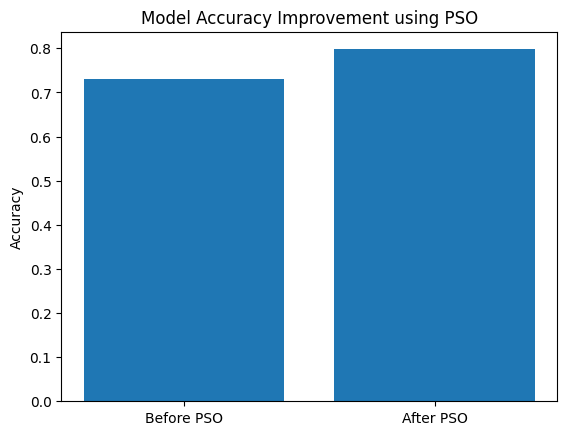

In [7]:
plt.figure()
plt.bar(["Before PSO", "After PSO"], [baseline_acc, final_acc])
plt.title("Model Accuracy Improvement using PSO")
plt.ylabel("Accuracy")
plt.show()

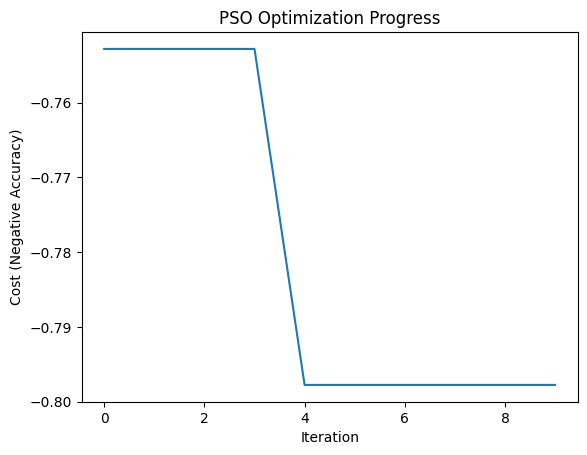

In [8]:
plt.figure()
plt.plot(optimizer.cost_history)
plt.title("PSO Optimization Progress")
plt.xlabel("Iteration")
plt.ylabel("Cost (Negative Accuracy)")
plt.show()

## 📌 Applications of PSO

### 1. Machine Learning
- Hyperparameter tuning (used here)
- Feature selection

### 2. Image Processing
- Image segmentation
- Object detection

### 3. Network Optimization
- Routing optimization
- Traffic management

## ✅ Advantages
- Simple to implement
- Fast convergence
- No gradient needed (good for ML)

## ❌ Disadvantages
- Can get stuck in local optimum
- Needs parameter tuning (w, c1, c2)
- Results may vary (randomness)